In [1]:
from google.colab import drive
import os
import zipfile
import glob

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
DRIVE_ZIP_PATH = '/content/drive/My Drive/license1.zip'

LOCAL_DATASET_DIR = '/content/license1'
LOCAL_IMAGE_DIR = '/content/license1/images'
LOCAL_ANNOT_DIR = '/content/license1/annotations'

if os.path.exists(DRIVE_ZIP_PATH):
    print(f"Found {DRIVE_ZIP_PATH}. Extracting files...")

    if os.path.exists(LOCAL_DATASET_DIR):
        !rm -rf "$LOCAL_DATASET_DIR"

    with zipfile.ZipFile(DRIVE_ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall('/content')

    print("Extraction complete.")
else:
    print(f"ERROR: '{DRIVE_ZIP_PATH}' not found.")
    print("Please verify the correct location of your ZIP file in Google Drive.")

print("\n--- Checking for 'images' folder: ---")
if os.path.exists(LOCAL_IMAGE_DIR):
    print(" 'images' folder found.")
    !ls "$LOCAL_IMAGE_DIR" | head -n 5
else:
    print(" 'images' folder NOT found. Your ZIP may contain a deeper folder structure.")

print("\n--- Checking for 'annotations' folder: ---")
if os.path.exists(LOCAL_ANNOT_DIR):
    print(" 'annotations' folder found.")
    !ls "$LOCAL_ANNOT_DIR" | head -n 5
else:
    print(" 'annotations' folder NOT found. Your ZIP may contain a deeper folder structure.")

Found /content/drive/My Drive/license1.zip. Extracting files...
Extraction complete.

--- Checking for 'images' folder: ---
 'images' folder found.
0073797c-a755-4972-b76b-8ef2b31d44ab___new_IMG_20160315_071740.jpg.jpeg
00b42b2c-f193-4863-b92c-0245cbc816da___3e7fd381-0ae5-4421-8a70-279ee0ec1c61_Nissan-Terrano-Petrol-Review-Images-Black-Front-Angle.jpg
018b52e6-e9a1-42c2-8ce7-0617e8c8e021___3e7fd381-0ae5-4421-8a70-279ee0ec1c61_sbtb02_auto1.JPG
03273806-bb1e-48da-8c8b-a0133a90197a___2014-Skoda-Yeti-Test-Drive.jpg.jpeg
0369b20e-b432-4409-90f9-2420877aa386___8151536c79159a1557421da5f27f9f0e.jpg.jpeg

--- Checking for 'annotations' folder: ---
 'annotations' folder found.
0073797c-a755-4972-b76b-8ef2b31d44ab___new_IMG_20160315_071740.jpg.xml
00b42b2c-f193-4863-b92c-0245cbc816da___3e7fd381-0ae5-4421-8a70-279ee0ec1c61_Nissan-Terrano-Petrol-Review-Images-Black-Front-Angle.xml
018b52e6-e9a1-42c2-8ce7-0617e8c8e021___3e7fd381-0ae5-4421-8a70-279ee0ec1c61_sbtb02_auto1.xml
03273806-bb1e-48da-8c8b-a0

In [3]:
# ============================================================
#                    CONFIGURATION
# ============================================================

BASE_DIR = "/content"
DATASET_DIR = "/content/license1"

IMAGES_DIR = "/content/license1/images"
ANNOT_DIR = "/content/license1/annotations"

OUTPUT_DIR = "/content/license1/cropped_plates"
CSV_PATH = "/content/license1/plate_labels.csv"

os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_SIZE = (128, 64)

TIME_STEPS = 32

MAX_LEN = 10

CHARACTERS = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
num_classes = len(CHARACTERS) + 1

char_to_idx = {c: i for i, c in enumerate(CHARACTERS)}
idx_to_char = {i: c for c, i in char_to_idx.items()}

print(" Colab Configuration Loaded.")
print("Images:", IMAGES_DIR)
print("Annotations:", ANNOT_DIR)
print("Cropped plates will be saved to:", OUTPUT_DIR)

 Colab Configuration Loaded.
Images: /content/license1/images
Annotations: /content/license1/annotations
Cropped plates will be saved to: /content/license1/cropped_plates


In [4]:
!pip install python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 67.9 MB/s eta 0:00:00


In [5]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import random
import Levenshtein
from tqdm import tqdm
from xml.etree import ElementTree as ET
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization, Bidirectional,
    LSTM, Reshape, Permute, Dense, Dropout, Lambda
)
from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import SpatialDropout2D

In [6]:
# ============================================================
#            CROP LICENSE PLATES
# ============================================================

labels = []
count = 0

for xml_file in glob.glob(os.path.join(ANNOT_DIR, "*.xml")):
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()
        img_name = root.find("filename").text.strip()
        img_path = os.path.join(IMAGES_DIR, img_name)

        if not os.path.exists(img_path):
            continue

        img = cv2.imread(img_path)
        if img is None:
            continue

        for obj in root.findall("object"):
            plate_text = obj.find("name").text.strip()
            bbox = obj.find("bndbox")
            xmin = int(float(bbox.find("xmin").text))
            ymin = int(float(bbox.find("ymin").text))
            xmax = int(float(bbox.find("xmax").text))
            ymax = int(float(bbox.find("ymax").text))

            crop = img[ymin:ymax, xmin:xmax]
            if crop.size == 0:
                continue

            save_path = os.path.join(OUTPUT_DIR, f"plate_{count}.jpg")
            cv2.imwrite(save_path, crop)
            labels.append([save_path, plate_text])
            count += 1

    except Exception as e:
        print("Error:", e)

df = pd.DataFrame(labels, columns=["image", "plate_text"])
df.to_csv(CSV_PATH, index=False)
print(f" Cropped {len(df)} plates.")

 Cropped 1671 plates.


In [7]:
# ============================================================
#       DATA SPLIT + AUGMENTATION + CTC PREP
# ============================================================

def augment_image(image):
    h, w = image.shape[:2]

    angle = random.uniform(-5, 5)

    shear = random.uniform(-0.1, 0.1)

    scale = random.uniform(0.9, 1.1)

    M_rot = cv2.getRotationMatrix2D((w//2, h//2), angle, scale)

    M_shear = np.float32([[1, shear, 0], [0, 1, 0]])

    image = cv2.warpAffine(image, M_rot, (w, h), borderMode=cv2.BORDER_REPLICATE)
    image = cv2.warpAffine(image, M_shear, (w, h), borderMode=cv2.BORDER_REPLICATE)

    brightness = random.uniform(0.6, 1.4)
    image = np.clip(image.astype(np.float32) * brightness, 0, 255).astype('uint8')

    if random.random() < 0.3:
        noise = np.random.normal(0, 10**0.5, image.shape)
        image = np.clip(image + noise, 0, 255).astype('uint8')

    if random.random() < 0.3:
        kernel = np.ones((2,2), np.uint8)
        if random.random() < 0.5:
            image = cv2.erode(image, kernel, iterations=1)
        else:
            image = cv2.dilate(image, kernel, iterations=1)

    return image

def encode_label_ctc(text, max_len=MAX_LEN):
    text = ''.join([c for c in text.upper() if c in CHARACTERS])
    text = text[:max_len]
    label_ids = [char_to_idx[c] for c in text]
    label_len = len(label_ids)
    padded = label_ids + [-1] * (max_len - label_len)
    return padded, label_len


train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

X_train, y_train, y_train_lens = [], [], []
N_AUG = 10

for _, row in tqdm(train_df.iterrows(), total=len(train_df)):
    img_path = row["image"]
    text = row["plate_text"]
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    img_resized = cv2.resize(img, IMG_SIZE)
    X_train.append(img_resized)
    pad, llen = encode_label_ctc(text)
    y_train.append(pad)
    y_train_lens.append(llen)

    for _ in range(N_AUG):
        aug = augment_image(img)
        aug = cv2.resize(aug, IMG_SIZE)
        X_train.append(aug)
        pad, llen = encode_label_ctc(text)
        y_train.append(pad)
        y_train_lens.append(llen)

X_test, y_test, y_test_lens = [], [], []

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    img = cv2.imread(row["image"], cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_SIZE)
    X_test.append(img)
    pad, llen = encode_label_ctc(row["plate_text"])
    y_test.append(pad)
    y_test_lens.append(llen)

X_train = np.array(X_train).reshape(-1, IMG_SIZE[1], IMG_SIZE[0], 1) / 255.0
X_test  = np.array(X_test).reshape(-1, IMG_SIZE[1], IMG_SIZE[0], 1) / 255.0

y_train = np.array(y_train)
y_test  = np.array(y_test)

train_input_len = np.full((len(X_train), 1), TIME_STEPS)
test_input_len  = np.full((len(X_test), 1), TIME_STEPS)

train_label_len = np.array(y_train_lens).reshape(-1, 1)
test_label_len  = np.array(y_test_lens).reshape(-1, 1)

print("Dataset ready for CTC training.")

100%|██████████| 335/335 [00:00<00:00, 3073.17it/s]


✔ Dataset ready for CTC training.


In [8]:
# ============================================================
#     FULL CTC-CRNN LICENSE PLATE RECOGNITION PIPELINE
# ============================================================

# ============================================================
#                   CRNN + CTC MODEL
# ============================================================

inputs = Input(shape=(IMG_SIZE[1], IMG_SIZE[0], 1), name="image")

x = Conv2D(64, (3, 3), activation="relu", padding="same")(inputs)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(128, (3, 3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(256, (3, 3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 1))(x)
x = SpatialDropout2D(0.1)(x)

x = Conv2D(256, (3, 3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 1))(x)
x = SpatialDropout2D(0.1)(x)

x = Permute((2, 1, 3))(x)
x = Reshape((TIME_STEPS, 4 * 256))(x)

x = Dropout(0.5)(x)

x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.25))(x)

y_pred = Dense(num_classes, activation="softmax", name="softmax")(x)

labels = Input(shape=(MAX_LEN,), dtype="int32", name="labels")
input_length = Input(shape=(1,), dtype="int32", name="input_length")
label_length = Input(shape=(1,), dtype="int32", name="label_length")

ctc_loss = Lambda(
    lambda args: K.ctc_batch_cost(*args),
    name="ctc_loss"
)([labels, y_pred, input_length, label_length])

ctc_model = Model(
    inputs=[inputs, labels, input_length, label_length],
    outputs=ctc_loss
)

ctc_model.compile(optimizer="adam", loss=lambda y_true, y_pred: y_pred)
prediction_model = Model(inputs=inputs, outputs=y_pred)

print("CTC-CRNN model created.")

# ============================================================
#               TRAINING THE MODEL
# ============================================================

train_dummy = np.zeros((len(X_train),))
test_dummy = np.zeros((len(X_test),))
checkpoint = ModelCheckpoint(
    filepath=os.path.join(BASE_DIR, "ctc_best_model.keras"),
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,
    mode='min',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = ctc_model.fit(
    x={
        "image": X_train,
        "labels": y_train,
        "input_length": train_input_len,
        "label_length": train_label_len
    },
    y=train_dummy,
    validation_data=(
        {
            "image": X_test,
            "labels": y_test,
            "input_length": test_input_len,
            "label_length": test_label_len
        },
        test_dummy
    ),
    epochs=50,
    batch_size=32,
    callbacks=[checkpoint, early_stopping, reduce_lr]
)

print(" Training Complete.")


# ============================================================
#              SAVE TRAINED MODELS
# ============================================================

ctc_model.save(os.path.join(BASE_DIR, "ctc_training_model.h5"))
prediction_model.save(os.path.join(BASE_DIR, "ctc_inference_model.h5"))

print(" Models saved.")


# ============================================================
#            PREDICTION (GREEDY CTC DECODE)
# ============================================================

def ctc_greedy_decode(preds):
    pred_indices = np.argmax(preds, axis=2)[0]
    prev = -1
    output = []
    for p in pred_indices:
        if p != prev and p != (num_classes - 1):
            output.append(idx_to_char[p])
        prev = p
    return "".join(output)


def preprocess_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_SIZE)
    img = img.astype("float32") / 255.0
    img = img.reshape(1, IMG_SIZE[1], IMG_SIZE[0], 1)
    return img


def predict_plate(image_path):
    img = preprocess_image(image_path)
    preds = prediction_model.predict(img)
    return ctc_greedy_decode(preds)


# ============================================================
#           EVALUATION ON DATASET
# ============================================================

def cer(a, b):
    if len(a) == 0:
        return 1.0
    return Levenshtein.distance(a, b) / len(a)


def evaluate(df, max_samples=200):
    df_sample = df.sample(min(max_samples, len(df)))
    exact = 0
    total_cer = 0

    for _, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
        true = row["plate_text"].strip().upper()
        pred = predict_plate(row["image"]).strip().upper()

        total_cer += cer(true, pred)
        if true == pred:
            exact += 1

    exact_acc = exact / len(df_sample) * 100
    avg_cer = total_cer / len(df_sample) * 100

    print("\n===== CTC CRNN Evaluation =====")
    print(f"Exact Match Accuracy: {exact_acc:.2f}%")
    print(f"Average CER:          {avg_cer:.2f}%")
    return exact_acc, avg_cer


evaluate(df, 150)


✔ CTC-CRNN model created.
Epoch 1/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 29.1072
Epoch 1: val_loss improved from inf to 23.27794, saving model to /content/ctc_best_model.keras


/usr/local/lib/python3.12/dist-packages/keras/src/saving/serialization_lib.py:390: UserWarning: The object being serialized includes a `lambda`. This is unsafe. In order to reload the object, you will have to pass `safe_mode=False` to the loading function. Please avoid using `lambda` in the future, and use named Python functions instead. This is the `lambda` being serialized: ctc_model.compile(optimizer="adam", loss=lambda y_true, y_pred: y_pred)

  return {key: serialize_keras_object(value) for key, value in obj.items()}


460/460 ━━━━━━━━━━━━━━━━━━━━ 45s 76ms/step - loss: 29.0976 - val_loss: 23.2779 - learning_rate: 0.0010
Epoch 2/50
459/460 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 15.5941
Epoch 2: val_loss improved from 23.27794 to 10.52036, saving model to /content/ctc_best_model.keras
460/460 ━━━━━━━━━━━━━━━━━━━━ 33s 72ms/step - loss: 15.5849 - val_loss: 10.5204 - learning_rate: 0.0010
Epoch 3/50
459/460 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 9.4879
Epoch 3: val_loss improved from 10.52036 to 8.32620, saving model to /content/ctc_best_model.keras
460/460 ━━━━━━━━━━━━━━━━━━━━ 34s 74ms/step - loss: 9.4845 - val_loss: 8.3262 - learning_rate: 0.0010
Epoch 4/50
459/460 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 6.6468
Epoch 4: val_loss improved from 8.32620 to 7.22244, saving model to /content/ctc_best_model.keras
460/460 ━━━━━━━━━━━━━━━━━━━━ 33s 71ms/step - loss: 6.6453 - val_loss: 7.2224 - learning_rate: 0.0010
Epoch 5/50
459/460 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 5.0509
Epoch 5: val_loss impr

 Training Complete.
 Models saved.


  0%|          | 0/150 [00:00<?, ?it/s]

...

 99%|█████████▉| 149/150 [00:11<00:00, 14.48it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


100%|██████████| 150/150 [00:11<00:00, 13.27it/s]


===== CTC CRNN Evaluation =====
Exact Match Accuracy: 89.33%
Average CER:          3.49%


(89.33333333333333, 3.4944444444444445)

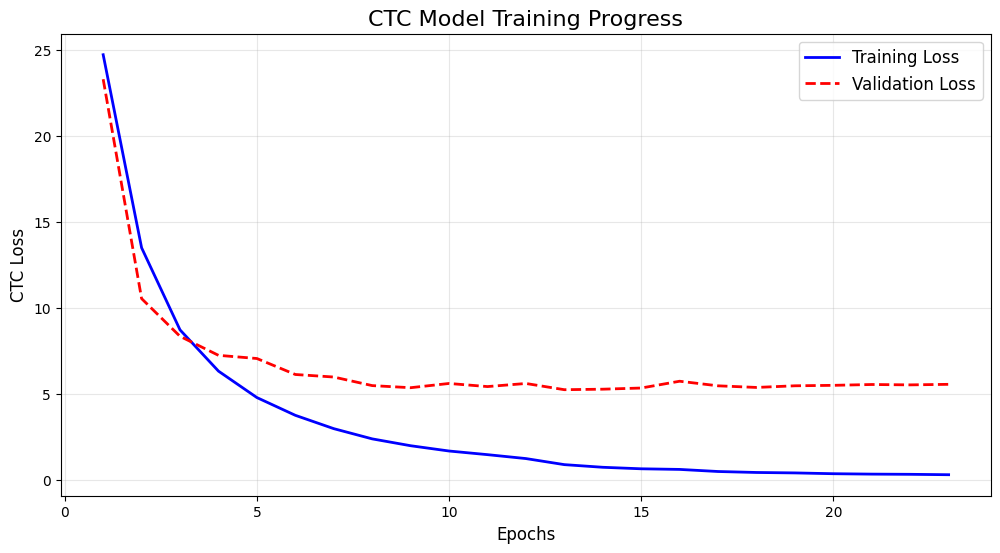

In [9]:
# ============================================================
#         VISUALIZE TRAINING HISTORY
# ============================================================
import matplotlib.pyplot as plt

def plot_history(history):
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(train_loss) + 1)

    plt.figure(figsize=(12, 6))
    plt.plot(epochs, train_loss, 'b-', linewidth=2, label='Training Loss')
    plt.plot(epochs, val_loss, 'r--', linewidth=2, label='Validation Loss')

    plt.title('CTC Model Training Progress', fontsize=16)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('CTC Loss', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)

    plt.show()

if 'history' in globals():
    plot_history(history)
else:
    print(" No training history found. Did you run Step 4?")

In [10]:
# ============================================================
#     FULL CTC-CRNN WITH ADAM-W LICENSE PLATE RECOGNITION PIPELINE
# ============================================================

# ============================================================
#                 CRNN + CTC MODEL
# ============================================================
inputs = Input(shape=(IMG_SIZE[1], IMG_SIZE[0], 1), name="image")

x = Conv2D(64, (3, 3), activation="relu", padding="same")(inputs)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(128, (3, 3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(256, (3, 3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 1))(x)
x = SpatialDropout2D(0.1)(x)

x = Conv2D(256, (3, 3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 1))(x)
x = SpatialDropout2D(0.1)(x)

x = Permute((2, 1, 3))(x)
x = Reshape((TIME_STEPS, 4 * 256))(x)

x = Dropout(0.5)(x)

x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.25))(x)

y_pred = Dense(num_classes, activation="softmax", name="softmax")(x)

labels = Input(shape=(MAX_LEN,), dtype="int32", name="labels")
input_length = Input(shape=(1,), dtype="int32", name="input_length")
label_length = Input(shape=(1,), dtype="int32", name="label_length")

ctc_loss = Lambda(
    lambda args: K.ctc_batch_cost(*args),
    name="ctc_loss"
)([labels, y_pred, input_length, label_length])

ctc_model = Model(
    inputs=[inputs, labels, input_length, label_length],
    outputs=ctc_loss
)


optimizer = tf.keras.optimizers.Adam(
    learning_rate=5e-5,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-7,
    clipnorm=3.0
)

ctc_model.compile(
    optimizer=optimizer,
    loss=lambda y_true, y_pred: y_pred
)

print("Adam model with regularization created.")

# ============================================================
#                TRAINING THE MODEL
# ============================================================

train_dummy = np.zeros((len(X_train),))
test_dummy  = np.zeros((len(X_test),))
checkpoint = ModelCheckpoint(
    filepath=os.path.join(BASE_DIR, "ctc_best_model.keras"),
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,
    mode='min',
    verbose=1
)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = ctc_model.fit(
    x={
        "image": X_train,
        "labels": y_train,
        "input_length": train_input_len,
        "label_length": train_label_len
    },
    y=train_dummy,
    validation_data=(
        {
            "image": X_test,
            "labels": y_test,
            "input_length": test_input_len,
            "label_length": test_label_len
        },
        test_dummy
    ),
    epochs=50,
    batch_size=32,
    callbacks=[checkpoint, early_stopping, reduce_lr]
)

print("✔ Training Complete.")

# ============================================================
#             SAVE TRAINED MODELS
# ============================================================

ctc_model.save(os.path.join(BASE_DIR, "adam_regularized_training_model.h5"))
prediction_model.save(os.path.join(BASE_DIR, "adam_regularized_inference_model.h5"))

print("✔ Models saved.")

# ============================================================
#           PREDICTION (GREEDY CTC DECODE)
# ============================================================

def ctc_greedy_decode(preds):
    pred_indices = np.argmax(preds, axis=2)[0]
    prev = -1
    output = []
    for p in pred_indices:
        if p != prev and p != (num_classes - 1):
            output.append(idx_to_char[p])
        prev = p
    return "".join(output)

def preprocess_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_SIZE)
    img = img.astype("float32") / 255.0
    img = img.reshape(1, IMG_SIZE[1], IMG_SIZE[0], 1)
    return img

def predict_plate(image_path):
    img = preprocess_image(image_path)
    preds = prediction_model.predict(img)
    return ctc_greedy_decode(preds)

# ============================================================
#           EVALUATION ON DATASET
# ============================================================

def cer(a, b):
    if len(a) == 0:
        return 1.0
    return Levenshtein.distance(a, b) / len(a)

def evaluate(df, max_samples=200):
    df_sample = df.sample(min(max_samples, len(df)))
    exact = 0
    total_cer = 0

    for _, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
        true = row["plate_text"].strip().upper()
        pred = predict_plate(row["image"]).strip().upper()

        total_cer += cer(true, pred)
        if true == pred:
            exact += 1

    exact_acc = exact / len(df_sample) * 100
    avg_cer = total_cer / len(df_sample) * 100

    print("\n===== CTC CRNN Evaluation (Adam-Regularized) =====")
    print(f"Exact Match Accuracy: {exact_acc:.2f}%")
    print(f"Average CER:          {avg_cer:.2f}%")
    return exact_acc, avg_cer

exact_acc, avg_cer = evaluate(df, 150)
print("Done.")

✔ Adam model with anti-overfitting regularization created.
Epoch 1/50
459/460 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 40.0649
Epoch 1: val_loss improved from inf to 72.13436, saving model to /content/ctc_best_model.keras


/usr/local/lib/python3.12/dist-packages/keras/src/saving/serialization_lib.py:390: UserWarning: The object being serialized includes a `lambda`. This is unsafe. In order to reload the object, you will have to pass `safe_mode=False` to the loading function. Please avoid using `lambda` in the future, and use named Python functions instead. This is the `lambda` being serialized:     loss=lambda y_true, y_pred: y_pred

  return {key: serialize_keras_object(value) for key, value in obj.items()}


460/460 ━━━━━━━━━━━━━━━━━━━━ 41s 75ms/step - loss: 40.0285 - val_loss: 72.1344 - learning_rate: 5.0000e-05
Epoch 2/50
459/460 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 26.4711
Epoch 2: val_loss improved from 72.13436 to 25.89281, saving model to /content/ctc_best_model.keras
460/460 ━━━━━━━━━━━━━━━━━━━━ 34s 74ms/step - loss: 26.4692 - val_loss: 25.8928 - learning_rate: 5.0000e-05
Epoch 3/50
459/460 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 24.8142
Epoch 3: val_loss improved from 25.89281 to 24.29673, saving model to /content/ctc_best_model.keras
460/460 ━━━━━━━━━━━━━━━━━━━━ 33s 73ms/step - loss: 24.8129 - val_loss: 24.2967 - learning_rate: 5.0000e-05
Epoch 4/50
459/460 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 23.4760
Epoch 4: val_loss improved from 24.29673 to 22.75938, saving model to /content/ctc_best_model.keras
460/460 ━━━━━━━━━━━━━━━━━━━━ 34s 74ms/step - loss: 23.4752 - val_loss: 22.7594 - learning_rate: 5.0000e-05
Epoch 5/50
459/460 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 22.4

✔ Training Complete.
✔ Models saved.


  0%|          | 0/150 [00:00<?, ?it/s]

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


 99%|█████████▉| 149/150 [00:11<00:00, 13.85it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


100%|██████████| 150/150 [00:11<00:00, 12.70it/s]


===== CTC CRNN Evaluation (Adam-Regularized) =====
Exact Match Accuracy: 87.33%
Average CER:          2.48%
Done.


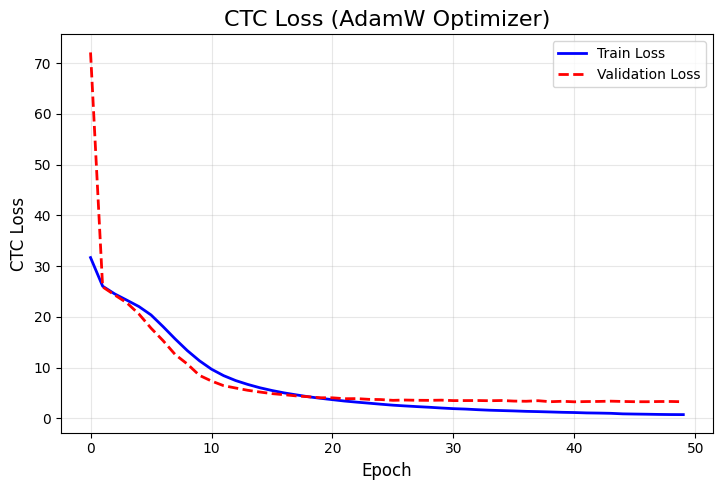

In [11]:
# ============================================================
#         VISUALIZE TRAINING HISTORY (ADAMW)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

def plot_history(history, optimizer=None):
    train_loss = history.history.get('loss', None)
    val_loss = history.history.get('val_loss', None)

    plt.figure(figsize=(14, 5))

    # ------------------- LOSS PLOT --------------------------
    plt.subplot(1, 2, 1)
    plt.plot(train_loss, label="Train Loss", color="blue", linewidth=2)
    if val_loss:
        plt.plot(val_loss, label="Validation Loss", color="red", linestyle='--', linewidth=2)
    plt.title("CTC Loss (AdamW Optimizer)", fontsize=16)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("CTC Loss", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)

    # ------------------- LR PLOT ----------------------------
    if optimizer is not None and hasattr(optimizer, '_decayed_lr'):
        try:
            lrs = [float(optimizer._decayed_lr(tf.float32).numpy()) for _ in train_loss]
            plt.subplot(1, 2, 2)
            plt.plot(lrs, label="Learning Rate", color="green")
            plt.title("Learning Rate Schedule (AdamW)", fontsize=16)
            plt.xlabel("Epoch", fontsize=12)
            plt.ylabel("LR Value", fontsize=12)
            plt.grid(True, alpha=0.3)
        except:
            pass

    plt.tight_layout()
    plt.show()


# ===================== CALL FUNCTION ======================
plot_history(history, optimizer)

In [12]:
# ============================================================
#     FULL CTC-CRNN LICENSE PLATE RECOGNITION PIPELINE
#     with AdamW_XT (trust factor + dynamic weight decay)
# ============================================================

# ============================================================
#                    CONFIGURATION
# ============================================================

BASE_DIR   = "/content/license1"
IMAGES_DIR = os.path.join(BASE_DIR, "images")
ANNOT_DIR  = os.path.join(BASE_DIR, "annotations")
OUTPUT_DIR = os.path.join(BASE_DIR, "cropped_plates")
CSV_PATH   = os.path.join(BASE_DIR, "plate_labels.csv")

os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_SIZE    = (128, 64)  # (W, H)
CHARACTERS  = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
char_to_idx = {c: i for i, c in enumerate(CHARACTERS)}
idx_to_char = {i: c for c, i in char_to_idx.items()}

MAX_LEN    = 10
num_classes = len(CHARACTERS) + 1
TIME_STEPS  = 32

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

# ============================================================
#              CROP LICENSE PLATES
# ============================================================

labels = []
count = 0

for xml_file in glob.glob(os.path.join(ANNOT_DIR, "*.xml")):
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()
        img_name = root.find("filename").text.strip()
        img_path = os.path.join(IMAGES_DIR, img_name)

        if not os.path.exists(img_path):
            continue

        img = cv2.imread(img_path)
        if img is None:
            continue

        for obj in root.findall("object"):
            plate_text = obj.find("name").text.strip()
            bbox = obj.find("bndbox")
            xmin = int(float(bbox.find("xmin").text))
            ymin = int(float(bbox.find("ymin").text))
            xmax = int(float(bbox.find("xmax").text))
            ymax = int(float(bbox.find("ymax").text))

            crop = img[ymin:ymax, xmin:xmax]
            if crop.size == 0:
                continue

            save_path = os.path.join(OUTPUT_DIR, f"plate_{count}.jpg")
            cv2.imwrite(save_path, crop)
            labels.append([save_path, plate_text])
            count += 1

    except Exception as e:
        print("Error:", xml_file, e)

df = pd.DataFrame(labels, columns=["image", "plate_text"])
df.to_csv(CSV_PATH, index=False)
print(f"Cropped {len(df)} plates and saved CSV at: {CSV_PATH}")

# If df is empty, stop early
if len(df) == 0:
    raise RuntimeError("No plates were cropped. Check IMAGES_DIR / ANNOT_DIR paths and XML contents.")

# ============================================================
#         DATA SPLIT + AUGMENTATION + CTC PREP
# ============================================================

def augment_image(image):
    h, w = image.shape[:2]

    angle = random.uniform(-5, 5)

    shear = random.uniform(-0.1, 0.1)

    scale = random.uniform(0.9, 1.1)

    M_rot = cv2.getRotationMatrix2D((w//2, h//2), angle, scale)
    M_shear = np.float32([[1, shear, 0], [0, 1, 0]])

    image = cv2.warpAffine(image, M_rot, (w, h), borderMode=cv2.BORDER_REPLICATE)
    image = cv2.warpAffine(image, M_shear, (w, h), borderMode=cv2.BORDER_REPLICATE)

    brightness = random.uniform(0.6, 1.4)
    image = np.clip(image.astype(np.float32) * brightness, 0, 255).astype('uint8')

    if random.random() < 0.3:
        noise = np.random.normal(0, 10**0.5, image.shape)
        image = np.clip(image + noise, 0, 255).astype('uint8')

    if random.random() < 0.3:
        kernel = np.ones((2,2), np.uint8)
        if random.random() < 0.5:
            image = cv2.erode(image, kernel, iterations=1)
        else:
            image = cv2.dilate(image, kernel, iterations=1)

    return image


def encode_label_ctc(text, max_len=MAX_LEN):
    text = ''.join([c for c in text.upper() if c in CHARACTERS])
    text = text[:max_len]
    label_ids = [char_to_idx[c] for c in text]
    label_len = len(label_ids)
    padded = label_ids + [-1] * (max_len - label_len)
    return padded, label_len


train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

X_train, y_train, y_train_lens = [], [], []
N_AUG = 10

print("Building training set with augmentation...")
for _, row in tqdm(train_df.iterrows(), total=len(train_df)):
    img_path = row["image"]
    text = row["plate_text"]
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    img_resized = cv2.resize(img, IMG_SIZE)
    X_train.append(img_resized)
    pad, llen = encode_label_ctc(text)
    y_train.append(pad)
    y_train_lens.append(llen)

    for _ in range(N_AUG):
        aug = augment_image(img)
        aug = cv2.resize(aug, IMG_SIZE)
        X_train.append(aug)
        pad, llen = encode_label_ctc(text)
        y_train.append(pad)
        y_train_lens.append(llen)

X_test, y_test, y_test_lens = [], [], []

print("Building test set (no augmentation)...")
for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    img = cv2.imread(row["image"], cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    img = cv2.resize(img, IMG_SIZE)
    X_test.append(img)
    pad, llen = encode_label_ctc(row["plate_text"])
    y_test.append(pad)
    y_test_lens.append(llen)

X_train = np.array(X_train).reshape(-1, IMG_SIZE[1], IMG_SIZE[0], 1) / 255.0
X_test  = np.array(X_test ).reshape(-1, IMG_SIZE[1], IMG_SIZE[0], 1) / 255.0

y_train = np.array(y_train)
y_test  = np.array(y_test)

train_input_len = np.full((len(X_train), 1), TIME_STEPS)
test_input_len  = np.full((len(X_test), 1), TIME_STEPS)

train_label_len = np.array(y_train_lens).reshape(-1, 1)
test_label_len  = np.array(y_test_lens).reshape(-1, 1)

print("✔ Dataset ready for CTC training.")
print("  X_train:", X_train.shape, "| y_train:", y_train.shape)
print("  X_test :", X_test.shape,  "| y_test :", y_test.shape)

# ============================================================
#                    CRNN + CTC MODEL
# ============================================================


inputs = Input(shape=(IMG_SIZE[1], IMG_SIZE[0], 1), name="image")

x = Conv2D(64, (3, 3), activation="relu", padding="same")(inputs)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(128, (3, 3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(256, (3, 3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 1))(x)
x = SpatialDropout2D(0.1)(x)

x = Conv2D(256, (3, 3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 1))(x)
x = SpatialDropout2D(0.1)(x)

x = Permute((2, 1, 3))(x)
x = Reshape((TIME_STEPS, 4 * 256))(x)

x = Dropout(0.5)(x)

x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.25))(x)

y_pred = Dense(num_classes, activation="softmax", name="softmax")(x)

labels = Input(shape=(MAX_LEN,), dtype="int32", name="labels")
input_length = Input(shape=(1,), dtype="int32", name="input_length")
label_length = Input(shape=(1,), dtype="int32", name="label_length")

ctc_loss = Lambda(
    lambda args: K.ctc_batch_cost(*args),
    name="ctc_loss"
)([labels, y_pred, input_length, label_length])

ctc_model = Model(
    inputs=[inputs, labels, input_length, label_length],
    outputs=ctc_loss
)

prediction_model = Model(inputs=inputs, outputs=y_pred)

# ============================================================
#   ADAMW_XT (trust factor + dynamic weight decay)
# ============================================================
import tensorflow as tf

try:
    from tensorflow.keras.optimizers import AdamW
except ImportError:
    from tensorflow.keras.optimizers.experimental import AdamW


class AdamW_XT(AdamW):
    def __init__(
        self,
        learning_rate=1e-4,
        base_weight_decay=1e-5,
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-7,
        trust_factor=0.1,
        wd_decay_rate=0.99,
        wd_min=1e-6,
        name="AdamW_XT",
        **kwargs
    ):
        super().__init__(
            learning_rate=learning_rate,
            weight_decay=0.0,
            beta_1=beta_1,
            beta_2=beta_2,
            epsilon=epsilon,
            name=name,
            **kwargs,
        )
        self.base_weight_decay = float(base_weight_decay)
        self.trust_factor = float(trust_factor)
        self.wd_decay_rate = float(wd_decay_rate)
        self.wd_min = float(wd_min)

    def update_step(self, gradient, variable, learning_rate):

        lr_t = tf.cast(learning_rate, variable.dtype)

        if self.trust_factor > 0.0:
            grad_norm = tf.norm(gradient)
            var_norm = tf.norm(variable)

            scale = tf.where(
                var_norm > 0.0,
                tf.minimum(
                    1.0,
                    self.trust_factor * var_norm / (grad_norm + 1e-8)
                ),
                1.0,
            )
            gradient = gradient * scale

        super().update_step(gradient, variable, lr_t)

        step = tf.cast(self.iterations + 1, tf.float32)

        wd_eff = self.base_weight_decay * (self.wd_decay_rate ** (step / 1000.0))
        wd_eff = tf.maximum(wd_eff, self.wd_min)
        wd_eff = tf.cast(wd_eff, variable.dtype)

        variable.assign_sub(lr_t * wd_eff * variable)


optimizer = AdamW_XT(
    learning_rate=1e-4,
    base_weight_decay=1e-5,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-7,
    trust_factor=0.2,
    wd_decay_rate=0.98,
    wd_min=1e-6,
    clipnorm=5.0
)

ctc_model.compile(
    optimizer=optimizer,
    loss=lambda y_true, y_pred: y_pred
)

print("✔ CTC-CRNN model with AdamW_XT created.")


# ============================================================
#                         CALLBACK
# ============================================================
checkpoint = ModelCheckpoint(
    filepath=os.path.join(BASE_DIR, "ctc_best_model.keras"), # Use .keras format
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,
    mode='min',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)


# ============================================================
#                TRAINING THE MODEL
# ============================================================
train_dummy = np.zeros((len(X_train),))
test_dummy  = np.zeros((len(X_test),))

history = ctc_model.fit(
    x={
        "image": X_train,
        "labels": y_train,
        "input_length": train_input_len,
        "label_length": train_label_len
    },
    y=train_dummy,
    validation_data=(
        {
            "image": X_test,
            "labels": y_test,
            "input_length": test_input_len,
            "label_length": test_label_len
        },
        test_dummy
    ),
    epochs=50,
    batch_size=32,
    callbacks=[checkpoint, early_stopping, reduce_lr]
)

print("✔ Training Complete.")

# ============================================================
#                   SAVE TRAINED MODELS
# ============================================================

ctc_model.save(os.path.join(BASE_DIR, "ctc_training_model_xt.h5"))
prediction_model.save(os.path.join(BASE_DIR, "ctc_inference_model_xt.h5"))

print("✔ Models saved to:", BASE_DIR)

# ============================================================
#               PREDICTION (GREEDY CTC DECODE)
# ============================================================

def ctc_greedy_decode(preds):
    pred_indices = np.argmax(preds, axis=2)[0]
    prev = -1
    output = []
    for p in pred_indices:
        if p != prev and p != (num_classes - 1):
            output.append(idx_to_char[p])
        prev = p
    return "".join(output)


def preprocess_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_SIZE)
    img = img.astype("float32") / 255.0
    img = img.reshape(1, IMG_SIZE[1], IMG_SIZE[0], 1)
    return img


def predict_plate(image_path):
    img = preprocess_image(image_path)
    preds = prediction_model.predict(img)
    return ctc_greedy_decode(preds)

# ============================================================
#               EVALUATION ON DATASET
# ============================================================

def cer(a, b):
    if len(a) == 0:
        return 1.0
    return Levenshtein.distance(a, b) / len(a)


def evaluate(df, max_samples=200):
    df_sample = df.sample(min(max_samples, len(df)))
    exact = 0
    total_cer = 0

    for _, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
        true = row["plate_text"].strip().upper()
        pred = predict_plate(row["image"]).strip().upper()

        total_cer += cer(true, pred)
        if true == pred:
            exact += 1

    exact_acc = exact / len(df_sample) * 100
    avg_cer = total_cer / len(df_sample) * 100

    print("\n===== CTC CRNN Evaluation (AdamW_XT) =====")
    print(f"Exact Match Accuracy: {exact_acc:.2f}%")
    print(f"Average CER:          {avg_cer:.2f}%")
    return exact_acc, avg_cer


exact_acc, avg_cer = evaluate(df, 150)
print("Done. Acc = %.2f%%, CER = %.2f%%" % (exact_acc, avg_cer))


Cropped 1671 plates and saved CSV at: /content/license1/plate_labels.csv
Building training set with augmentation...


100%|██████████| 1336/1336 [00:07<00:00, 173.28it/s]


Building test set (no augmentation)...


100%|██████████| 335/335 [00:00<00:00, 3751.38it/s]


✔ Dataset ready for CTC training.
  X_train: (14696, 64, 128, 1) | y_train: (14696, 10)
  X_test : (335, 64, 128, 1) | y_test : (335, 10)
✔ CTC-CRNN model with AdamW_XT created.
Epoch 1/50
459/460 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 35.4082
Epoch 1: val_loss improved from inf to 64.65033, saving model to /content/license1/ctc_best_model.keras
460/460 ━━━━━━━━━━━━━━━━━━━━ 44s 79ms/step - loss: 35.3815 - val_loss: 64.6503 - learning_rate: 1.0000e-04
Epoch 2/50
459/460 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 25.0319
Epoch 2: val_loss improved from 64.65033 to 23.43126, saving model to /content/license1/ctc_best_model.keras
460/460 ━━━━━━━━━━━━━━━━━━━━ 35s 76ms/step - loss: 25.0295 - val_loss: 23.4313 - learning_rate: 1.0000e-04
Epoch 3/50
459/460 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 22.7472
Epoch 3: val_loss improved from 23.43126 to 18.87142, saving model to /content/license1/ctc_best_model.keras
460/460 ━━━━━━━━━━━━━━━━━━━━ 42s 77ms/step - loss: 22.7441 - val_loss: 18.8714 

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


 99%|█████████▊| 148/150 [00:10<00:00, 15.80it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


100%|██████████| 150/150 [00:11<00:00, 13.56it/s]


===== CTC CRNN Evaluation (AdamW_XT) =====
Exact Match Accuracy: 93.33%
Average CER:          1.46%
Done. Acc = 93.33%, CER = 1.46%


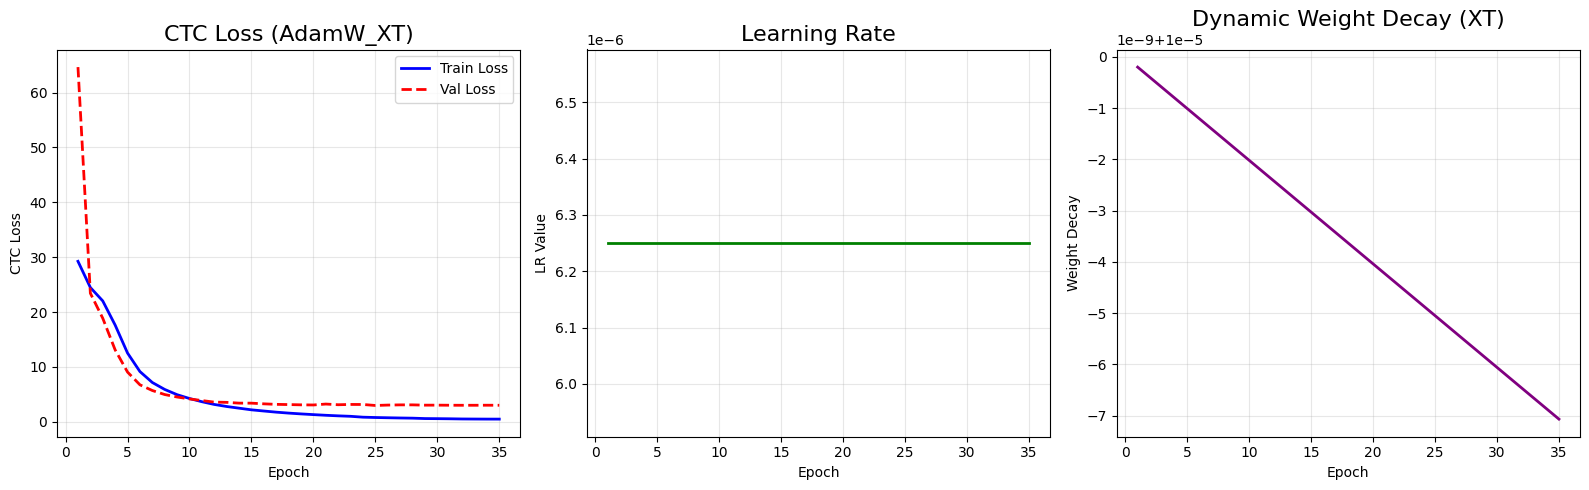

In [13]:
# ============================================================
#           VISUALIZE TRAINING HISTORY (AdamW_XT)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

def plot_history(history, optimizer=None):
    train_loss = history.history.get("loss", None)
    val_loss   = history.history.get("val_loss", None)

    epochs = np.arange(1, len(train_loss) + 1)

    plt.figure(figsize=(16, 5))

    # ============================================================
    #                  PLOT 1 — LOSS CURVE
    # ============================================================
    plt.subplot(1, 3, 1)
    plt.plot(epochs, train_loss, label="Train Loss", color="blue", linewidth=2)
    if val_loss:
        plt.plot(epochs, val_loss, label="Val Loss", color="red", linestyle="--", linewidth=2)

    plt.title("CTC Loss (AdamW_XT)", fontsize=16)
    plt.xlabel("Epoch")
    plt.ylabel("CTC Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # ============================================================
    #         PLOT 2 — LEARNING RATE (constant for AdamW)
    # ============================================================
    if optimizer is not None:
        plt.subplot(1, 3, 2)
        lr = float(tf.keras.backend.get_value(optimizer.learning_rate))
        plt.plot(epochs, [lr] * len(epochs), color="green", linewidth=2)
        plt.title("Learning Rate", fontsize=16)
        plt.xlabel("Epoch")
        plt.ylabel("LR Value")
        plt.grid(True, alpha=0.3)

    # ============================================================
    #      PLOT 3 — DYNAMIC WEIGHT DECAY (XT custom decay)
    # ============================================================
    if optimizer is not None and hasattr(optimizer, "base_weight_decay"):
        plt.subplot(1, 3, 3)

        base_wd = optimizer.base_weight_decay
        decay   = optimizer.wd_decay_rate
        wd_min  = optimizer.wd_min

        wd_values = [
            max(base_wd * (decay ** (step / 1000.0)), wd_min)
            for step in range(1, len(epochs) + 1)
        ]

        plt.plot(epochs, wd_values, color="purple", linewidth=2)
        plt.title("Dynamic Weight Decay (XT)", fontsize=16)
        plt.xlabel("Epoch")
        plt.ylabel("Weight Decay")
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history, optimizer)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 963.8/963.8 kB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 30.1 MB/s eta 0:00:00


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete✔ EasyOCR initialized.
Running EasyOCR on all 1336 training images...


100%|██████████| 1336/1336 [00:32<00:00, 41.65it/s]


✔ Processed 1336 images.
===== Top 150 EasyOCR Predictions =====
Average CER: 0.0000
Exact Matches: 150/150

--- Sample of Best Predictions ---


,true_text,pred_text,cer
1,MH02CD3654,MH02CD3654,0.0
6,TN28BA9999,TN28BA9999,0.0
9,MH03CS6266,MH03CS6266,0.0
10,MH47Y1124,MH47Y1124,0.0
11,MH01AX3070,MH01AX3070,0.0
35,MH01AV8814,MH01AV8814,0.0
36,TN07BU5427,TN07BU5427,0.0
42,MH47Y1124,MH47Y1124,0.0
56,MH47Y1124,MH47Y1124,0.0
67,RJ27TC0530,RJ27TC0530,0.0


Visualizing top 5 easiest plates for EasyOCR:


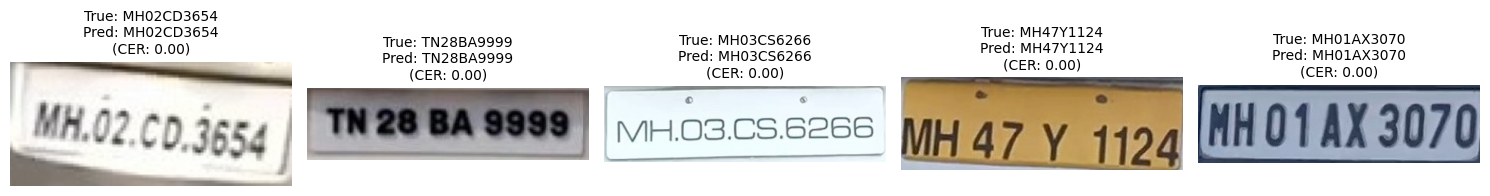

In [ ]:
!pip install easyocr

import easyocr

reader = easyocr.Reader(['en'], gpu=True)

print("EasyOCR initialized.")

import easyocr
import pandas as pd
import Levenshtein
from tqdm import tqdm
reader = easyocr.Reader(['en'], gpu=True)

ALLOWED_CHARS = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"

full_results = []

print(f"Running EasyOCR on all {len(train_df)} training images...")

for index, row in tqdm(train_df.iterrows(), total=len(train_df)):
    img_path = row["image"]
    true_text = row["plate_text"].strip().upper()

    try:
        preds = reader.readtext(img_path, detail=0, allowlist=ALLOWED_CHARS)

        if len(preds) > 0:
            pred_text = "".join(preds).strip().upper()
        else:
            pred_text = ""

        if len(true_text) > 0:
            cer = Levenshtein.distance(true_text, pred_text) / len(true_text)
        else:
            cer = 1.0 if len(pred_text) > 0 else 0.0

        is_exact = 1 if pred_text == true_text else 0

        full_results.append({
            "image_path": img_path,
            "true_text": true_text,
            "pred_text": pred_text,
            "cer": cer,
            "exact_match": is_exact
        })

    except Exception as e:
        print(f"Error reading {img_path}: {e}")

ocr_results_df = pd.DataFrame(full_results)

print(f"\n Processed {len(ocr_results_df)} images.")

best_150_df = ocr_results_df.sort_values(
    by=["exact_match", "cer"],
    ascending=[False, True]
).head(150)

print(f"===== Top 150 EasyOCR Predictions =====")
print(f"Average CER: {best_150_df['cer'].mean():.4f}")
print(f"Exact Matches: {best_150_df['exact_match'].sum()}/{len(best_150_df)}")

print("\n--- Sample of Best Predictions ---")
display(best_150_df[["true_text", "pred_text", "cer"]].head(10))

import matplotlib.pyplot as plt
import cv2

def show_best_samples(df, num_show=5):
    plt.figure(figsize=(15, 5))

    for i in range(num_show):
        row = df.iloc[i]
        img_path = row['image_path']

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, num_show, i + 1)
        plt.imshow(img)
        plt.title(f"True: {row['true_text']}\nPred: {row['pred_text']}\n(CER: {row['cer']:.2f})", fontsize=10)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

print("Visualizing top 5 easiest plates for EasyOCR:")
show_best_samples(best_150_df, 5)

✔ Adam-Regularized model loaded.


✔ AdamW_XT model loaded.

Showing predictions from BOTH models for 5 images...



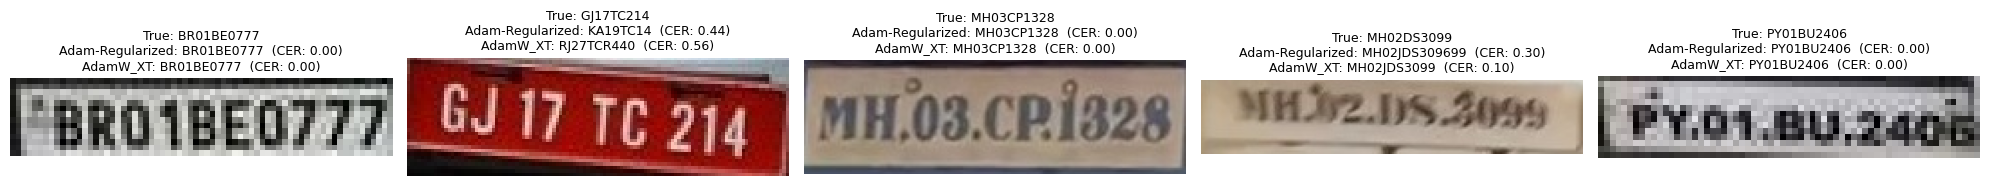

In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import backend as K
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import Levenshtein

BASE_DIR = "/content"
DATASET_DIR = "/content/license1"

IMAGES_DIR = "/content/license1/images"
OUTPUT_DIR  = "/content/license1/cropped_plates"
CSV_PATH    = "/content/license1/plate_labels.csv"

IMG_SIZE = (128, 64)
MAX_LEN = 10
CHARACTERS = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"

num_classes = len(CHARACTERS) + 1
idx_to_char = {i: c for i, c in enumerate(CHARACTERS)}

def preprocess_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_SIZE)
    img = img.astype("float32") / 255.0
    img = img.reshape(1, IMG_SIZE[1], IMG_SIZE[0], 1)
    return img

def ctc_greedy_decode(preds):
    blank = num_classes - 1
    pred_idx = np.argmax(preds, axis=2)[0]
    output = []
    prev = -1
    for p in pred_idx:
        if p != prev and p != blank:
            output.append(idx_to_char.get(p, ""))
        prev = p
    return "".join(output)

def compute_cer(a, b):
    if len(a) == 0:
        return 1.0
    return Levenshtein.distance(a, b) / len(a)

models = {}

adam_reg_path = "/content/adam_regularized_inference_model.h5"
if os.path.exists(adam_reg_path):
    models["Adam-Regularized"] = tf.keras.models.load_model(
        adam_reg_path,
        custom_objects={'<lambda>': lambda y_true, y_pred: y_pred},
        safe_mode=False
    )
    print("Adam-Regularized model loaded.")
else:
    print(" Missing Adam-Regularized model at:", adam_reg_path)

xt_path = "/content/license1/ctc_inference_model_xt.h5"
if os.path.exists(xt_path):
    models["AdamW_XT"] = tf.keras.models.load_model(
        xt_path,
        custom_objects={'<lambda>': lambda y_true, y_pred: y_pred},
        safe_mode=False
    )
    print("AdamW_XT model loaded.")
else:
    print(" Missing AdamW_XT model at:", xt_path)

def show_dual_model_predictions(df, models_dict, num_samples=5):
    samples = df.sample(num_samples)

    plt.figure(figsize=(20, 4))

    for idx, row in enumerate(samples.itertuples(), 1):
        true_text = row.plate_text.strip().upper()
        img_path  = row.image

        raw = cv2.imread(img_path)
        raw = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)

        img = preprocess_image(img_path)

        preds_info = []
        for name, model in models_dict.items():
            preds = model.predict(img, verbose=0)
            decoded = ctc_greedy_decode(preds)
            cer = compute_cer(true_text, decoded)
            preds_info.append(f"{name}: {decoded}  (CER: {cer:.2f})")

        ax = plt.subplot(1, num_samples, idx)
        title = f"True: {true_text}\n" + "\n".join(preds_info)
        ax.set_title(title, fontsize=9)

        plt.imshow(raw)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

if not models:
    print(" Cannot run inference — no models loaded.")
else:
    df = pd.read_csv(CSV_PATH)

    _, test_df = train_test_split(df, test_size=0.2, random_state=42)

    print("\nShowing predictions from BOTH models for 5 images...\n")
    show_dual_model_predictions(test_df, models, num_samples=5)

